# Cantilever beam plant bending model

This notebook computes the transverse deflection $w(x)$ of a cantilever beam on
$x \in [0,L]$ with flexural stiffness $EI(x)$ computed from concentric petiole
layers and distributed load $q(x)$. There is no concentrated force or applied
moment at the free end $x=L$. The coordinate $x$ points from the clamped end to
the free end, the deflection $w(x)$ is positive upward, positive $q(x)$ acts
upward, and positive bending moment $M(x)$ acts counterclockwise.

In [1]:
# Import numerical and plotting tools
from scipy.integrate import cumulative_trapezoid
import matplotlib.pyplot as plt
import numpy as np

## Petiole geometry and flexural stiffness

The petiole is modelled as $N$ concentric circular material layers. The input layer thicknesses are $l_i(x)$ for $i=0,\ldots,N-1$, which may vary along the petiole. The boundary
radii are

$$
r_0(x)=0,
\qquad
r_{i+1}(x)=r_i(x)+l_i(x).
$$

For bending about a centroidal diameter, layer $i$ has second moment of area

$$
I_i(x)=\frac{\pi}{4}\left(r_{i+1}(x)^4-r_i(x)^4\right).
$$

With constant layer moduli $E_i$, the flexural stiffness is

$$
EI(x)=\sum_{i=0}^{N-1} E_i I_i(x).
$$

In [ ]:
# Set the beam grid and simple layer definitions
L = 1.0
N_grid_points = 2001
x = np.linspace(0.0, L, N_grid_points)

layer_names = ("pith", "vascular", "ground tissue")
layer_colors = ("#f2c94c", "#8ecae6", "#9b5de5")
N = len(layer_names)

# Define sampled layer thicknesses on the grid
pith_thickness = 0.01 * np.ones_like(x)
vascular_thickness = 0.005 * np.ones_like(x)
ground_tissue_thickness = 0.002 * np.ones_like(x)

# Define constant elastic moduli for each layer
pith_modulus = 12.0
vascular_modulus = 25.0
ground_tissue_modulus = 8.0
moduli = np.array((pith_modulus, vascular_modulus, ground_tissue_modulus))

# Matrix with one row per layer and one column per grid point
thicknesses = np.vstack((
    pith_thickness,
    vascular_thickness,
    ground_tissue_thickness,
))

# Accumulate thicknesses to get boundary radii for each layer at each grid point
radii = np.vstack((np.zeros_like(x), np.cumsum(thicknesses, axis=0)))

# Compute the layer second moments from adjacent boundary radii
inner_radii = radii[:-1]
outer_radii = radii[1:]
layer_second_moments = np.pi * (outer_radii**4 - inner_radii**4) / 4.0

# Sum the layer contributions to get one EI value per grid point
layer_flexural_stiffness = moduli[:, np.newaxis] * layer_second_moments
EI = np.sum(layer_flexural_stiffness, axis=0)

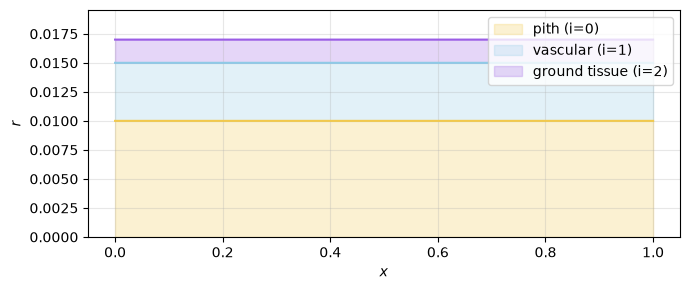

In [ ]:
# Plot the longitudinal boundary radii of the concentric layers
fig, ax = plt.subplots(figsize=(7, 3))

layer_plot_data = zip(layer_names, layer_colors, radii[:-1], radii[1:])

for i, (layer_name, layer_color, inner_radius, outer_radius) in enumerate(layer_plot_data):
    ax.fill_between(
        x,
        inner_radius,
        outer_radius,
        color=layer_color,
        alpha=0.25,
        label=f"{layer_name} (i={i})",
    )
    ax.plot(x, outer_radius, color=layer_color)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$r$")
ax.set_ylim(0.0, 1.15 * np.max(radii[-1]))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Euler-Bernoulli beam model

The Euler-Bernoulli beam equation is given by

$$
\frac{d^2}{dx^2}\left(EI(x)\,\frac{d^2w}{dx^2}(x)\right)=q(x),
\qquad 0<x<L.
$$

For a cantilever beam, the clamped end at $x=0$ has zero deflection and zero
slope:

$$
w(0)=0, \qquad \frac{dw}{dx}(0)=0.
$$

The boundary conditions at the free end at $x=L$ are given by

$$
M(L)=0, \qquad \frac{dM}{dx}(L)=0,
$$

where the bending moment is given by

$$
M(x)=EI(x)\,\frac{d^2w}{dx^2}(x).
$$

Expressing the governing equation in terms of the bending moment, we have

$$
\frac{d^2M}{dx^2}(x)=q(x).
$$

Integrating both sides of the above equation from the free end at $x=L$ to a given point $x$ and using the boundary condition $M'(L)=0$, we get
$$
\frac{dM}{dx}(x)=-Q(x),
$$
where we define
$$
Q(x)=\int_x^L q(r)\,dr.
$$
Next, we integrate from the free end again and use the boundary condition $M(L)=0$ to obtain
$$
M(x)=\int_x^L Q(s)\,ds.
$$
Expressing the curvature in terms of the bending moment as
$$
\frac{d^2w}{dx^2}(x)=\frac{M(x)}{EI(x)},
$$
we can integrate from $x=0$ and use the boundary condition $w'(0)=0$ to obtain
$$
\frac{dw}{dx}(x)=\int_0^x \frac{M(r)}{EI(r)}\,dr.
$$
Finally, we can integrate once more and use the boundary condition $w(0)=0$ to get the deflection:
$$
w(x)=\int_0^x \frac{dw}{dr}(r)\,dr.
$$

The code takes sampled values of $EI(x)$ and $q(x)$ on the grid, then evaluates these four cumulative integrations using the trapezoidal rule.

In [4]:
# Set a uniform distributed load and integrate using the trapezoidal rule
q = np.ones_like(x)

# Integrate q from the free end
Q = -cumulative_trapezoid(q[::-1], x[::-1], initial=0.0)[::-1]

# Integrate Q from the free end to get the bending moment M
M = -cumulative_trapezoid(Q[::-1], x[::-1], initial=0.0)[::-1]

# Divide by EI to get curvature, then integrate twice from the clamped end
dwdx = cumulative_trapezoid(M / EI, x, initial=0.0)
w = cumulative_trapezoid(dwdx, x, initial=0.0)

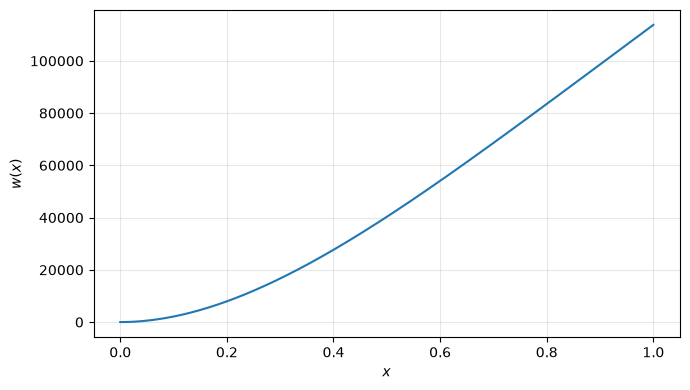

In [5]:
# Plot the computed deflection
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, w)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$w(x)$")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()